# Reproducing Shuntov et al. (2025b) with `halogal.inference`

**Goal.** Validate the new `halogal.inference` MCMC module by reproducing the
joint **clustering + UVLF** fit of Shuntov et al. (2025b, A&A 699, A231),
*"Star formation efficiency from clustering and halo modelling of H$\alpha$ and
[O III] emitters"*, at three redshift bins: H$\alpha$ $z\simeq4.3$,
H$\alpha$ $z\simeq5.4$, [O III] $z\simeq7.3$.

At each bin the likelihood combines:
- the **angular correlation function** $w(\theta)$ measurements
  (`examples/shuntov25_data/w-theta_measurements_*.ecsv`), and
- the **UV luminosity function** data points: Bouwens et al. (2021) literature
  points (`examples/bouwens21_data.py`) **plus** the paper's H$\alpha$/[O III]
  emitter UVLF points.

We then check that the posterior reproduces (a) the paper's best-fit $w(\theta)$
curves, (b) the paper's UVLF band, and (c) the published parameter values that
seed `halogal.config.DEFAULT_HOD_PARAMS` / `DEFAULT_REDSHIFT_EVOLUTION`.

> **Two inputs you must supply / check** (flagged `USER ACTION` below):
> 1. The H$\alpha$/[O III] **emitter UVLF data points** are not tabulated in
>    the public data repo (it ships only the best-fit UVLF *model*). Add them
>    from the paper's tables to fit the full likelihood; until then the cells
>    run with Bouwens-only UVLF + clustering.
> 2. The per-bin **magnitude threshold**, **redshift distribution $p(z)$**, and
>    the `halomod` model keywords (exclusion/transfer) that match *your*
>    installed `halomod` version.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import warnings; warnings.filterwarnings('ignore')
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

# Make the repo importable when running from notebooks/
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / 'examples'))

from halogal.inference import (Parameter, ParameterSet, Uniform, Normal,
                               ModelParametrization, Dataset, GaussianLikelihood,
                               EmceeSampler, DynestySampler)
from halogal.config import DEFAULT_HOD_PARAMS, DEFAULT_REDSHIFT_EVOLUTION
from bouwens21_data import bouwens21

try:
    plt.style.use('marko.mplstyle')
except OSError:
    pass

DATA = REPO / 'examples' / 'shuntov25_data'

# Keyword arguments forwarded to initialize_correlation_model. On the
# recommended halogal conda env (numpy<2) CAMB works, so we use it (accurate).
# znum/theta_num set the halomod redshift- and angle-grid resolution; 30 is
# plenty for these data and keeps the per-call cost down.
#  * If you are on numpy>=2 and hit a camb error
#    ('only 0-dimensional arrays can be converted to Python scalars'), add
#    transfer_model='EH' (analytic, no camb; an approximation).
#  * If you hit "model ... is not a defined Exclusion model", set a valid
#    exclusion_model for your halomod version (e.g. 'NgMatched' or 'DblSphere').
HALOMOD_KW = dict(znum=30, theta_num=30)

# Mass-grid resolution for the colossus HMF used by UVLF-only bins. The UVLF
# integral is smooth, so 256 points is ~2.6x faster than the 2048 default with
# <0.1% change in Phi. Bins that include clustering reuse the halomod HMF and
# ignore this. See the performance note below.
HMF_POINTS = 256

# Local processes for parallel sampling. Clustering likelihood calls are
# ~0.5-1 s each, so parallelise: EmceeSampler.run(processes=N) builds the
# (expensive) halomod model once per worker. Set to 1 to run serially.
import os
NPROC = max(1, (os.cpu_count() or 2) - 1)

## Data

Three redshift bins. Each maps to a clustering measurement file, the closest
Bouwens+2021 UVLF bin, and a magnitude threshold for the clustered sample.

In [2]:
BINS = {
    'ha-z4.3':   dict(z=4.3, bouwens='z4', muv_thresh=-20.0, line='Ha'),
    'ha-z5.4':   dict(z=5.4, bouwens='z5', muv_thresh=-20.0, line='Ha'),
    'oiii-z7.3': dict(z=7.3, bouwens='z7', muv_thresh=-20.0, line='OIII'),
}
# USER ACTION: set muv_thresh (and p(z)) to the paper's per-sample values.
# The provided Galaxy-bias_vs_z.ecsv reports bias for M_UV < -18, -19.1, -20, -21.

def load_wtheta(tag):
    t = Table.read(DATA / f'w-theta_measurements_{tag}.ecsv')
    return np.array(t['theta']), np.array(t['w']), np.array(t['w_err'])

def load_wtheta_bestfit(tag):
    t = Table.read(DATA / f'w-theta_best-fit-model_{tag}.ecsv')
    return (np.array(t['theta']), np.array(t['w_16']),
            np.array(t['w_50']), np.array(t['w_84']))

def load_uvlf_bestfit(zlabel):
    t = Table.read(DATA / f'UVLF_best-fit-model_z{zlabel}.ecsv')
    return (np.array(t['MUV']), np.array(t['Phi_16']),
            np.array(t['Phi_50']), np.array(t['Phi_84']))

def uvlf_points(cfg):
    """UVLF data points for a bin: Bouwens + (USER) emitter points."""
    bw = bouwens21[cfg['bouwens']]
    muv, phi, err = bw['M_AB'], bw['Fi_k'], bw['Fi_k_error']
    # USER ACTION: append the paper's Ha/[OIII] emitter UVLF points, e.g.:
    #   muv = np.concatenate([muv, emitter_muv])
    #   phi = np.concatenate([phi, emitter_phi])
    #   err = np.concatenate([err, emitter_err])
    return np.asarray(muv), np.asarray(phi), np.asarray(err)

for tag, cfg in BINS.items():
    th, w, werr = load_wtheta(tag)
    muv, phi, err = uvlf_points(cfg)
    print(f'{tag}: w(theta) n={len(th)},  UVLF n={len(muv)}')

ha-z4.3: w(theta) n=8,  UVLF n=12
ha-z5.4: w(theta) n=8,  UVLF n=12
oiii-z7.3: w(theta) n=8,  UVLF n=10


## Single-bin fit (fixed-$z$): H$\alpha$ $z\simeq5.4$

Joint UVLF + $w(\theta)$ at one redshift. We free the eight HOD parameters
(masses sampled in $\log_{10}$) with broad priors bracketing the published
values.

In [3]:
tag = 'ha-z5.4'
cfg = BINS[tag]
z = cfg['z']
th, w, werr = load_wtheta(tag)
muv, phi, err = uvlf_points(cfg)

uvlf_ds = Dataset.uvlf(z=z, MUV=muv, phi=phi, sigma=err, label=f'UVLF z{z}')
# A full covariance for w(theta) is preferable (theta bins correlate); the repo
# provides diagonal w_err, which matches the paper. Pass cov=... when available.
clu_ds = Dataset.clustering(
    z=z, theta=th, w=w, sigma=werr, MUV_thresh1=cfg['muv_thresh'],
    corr_kwargs=dict(correlation_type='angular', **HALOMOD_KW),
    label=f'w(theta) z{z}')

params = ParameterSet([
    Parameter('eps0',     Uniform(0.02, 0.40)),
    Parameter('logMc',    Uniform(10.5, 12.5)),
    Parameter('a',        Uniform(0.20, 1.20)),
    Parameter('b',        Uniform(0.20, 1.50)),
    Parameter('sigma_UV', Uniform(0.20, 1.30)),
    Parameter('logMcut',  Uniform(7.0, 12.0)),
    Parameter('logMsat',  Uniform(11.0, 14.0)),
    Parameter('asat',     Uniform(0.30, 1.50)),
])
like = GaussianLikelihood([uvlf_ds, clu_ds],
                          ModelParametrization('fixed_z', params),
                          hmf_points=HMF_POINTS)
like

GaussianLikelihood(2 datasets [clustering, uvlf], z=[5.4], mode='fixed_z')

**Sanity check before sampling.** `GaussianLikelihood.log_likelihood` uses
`catch_errors=True` by default: a model that raises is turned into `-inf` so a
single bad sample never kills a long chain. The downside is that a *systematic*
failure (e.g. a halomod/camb misconfiguration) would silently make every sample
`-inf` and only surface later. `like.check()` evaluates each dataset once with
all errors **surfaced** -- run it first to confirm the setup is healthy. (Setup
errors in `initialize_correlation_model` now also propagate from
`log_likelihood` itself rather than being masked.)

In [4]:
# Per-dataset log-likelihood at the fiducial parameters; raises on a real error.
like.check()

{'UVLF z5.4': -2934.078180492684, 'w(theta) z5.4': -6355.881872394735}

**Cost & parallelism.** Each clustering likelihood call is ~0.5-1 s (the
halomod angular correlation function), so the wall time is
`~0.7 s x nwalkers x nsteps / NPROC`. A serial 64-walker x 1000-step chain is
**~11 hours** -- one step every ~40 s, which looks frozen. Always parallelise
with `processes=NPROC` (the likelihood is built once per worker) and start with
a short chain to confirm it moves, then scale up. For a real, long run use the
standalone script `examples/fit_shuntov25.py` rather than the notebook.

In [5]:
# SHORT demo chain so you can see it move and get a (rough) result quickly.
# Increase nsteps to a few thousand for a converged posterior.
result = EmceeSampler(params, like).run(
    nwalkers=24, nsteps=200, processes=NPROC, progress=True)
print(result)
print('acceptance fraction:', result.extras['acceptance_fraction'])

/Users/mshuntov/opt/anaconda3/envs/halogal/lib/python3.12/site-packages/hmf/density_field/transfer.py:230: UserWarning: 'extrapolate_with_eh' was not set. Defaulting to True, which is different behaviour than versions <=3.4.4. This warning may be removed in v4.0. Silence it by setting extrapolate_with_eh explicitly.
  return self.transfer_model(self.cosmo, **self.transfer_params)
/Users/mshuntov/opt/anaconda3/envs/halogal/lib/python3.12/site-packages/hmf/density_field/transfer.py:230: UserWarning: 'extrapolate_with_eh' was not set. Defaulting to True, which is different behaviour than versions <=3.4.4. This warning may be removed in v4.0. Silence it by setting extrapolate_with_eh explicitly.
  return self.transfer_model(self.cosmo, **self.transfer_params)
/Users/mshuntov/opt/anaconda3/envs/halogal/lib/python3.12/site-packages/hmf/density_field/transfer.py:230: UserWarning: 'extrapolate_with_eh' was not set. Defaulting to True, which is different behaviour than versions <=3.4.4. This wa

InferenceResult (backend=emcee, nsamples=3216)
            eps0 = 0.1471 (+0.0365 / -0.0164)
           logMc = 10.53 (+0.0615 / -0.0179)
               a = 0.7933 (+0.0361 / -0.0533)
               b = 1.377 (+0.0952 / -0.341)
        sigma_UV = 1.155 (+0.0908 / -0.152)
         logMcut = 9.043 (+0.342 / -0.331)
         logMsat = 12.85 (+0.762 / -0.389)
            asat = 0.8031 (+0.0629 / -0.055)
acceptance fraction: 0.4014583333333333


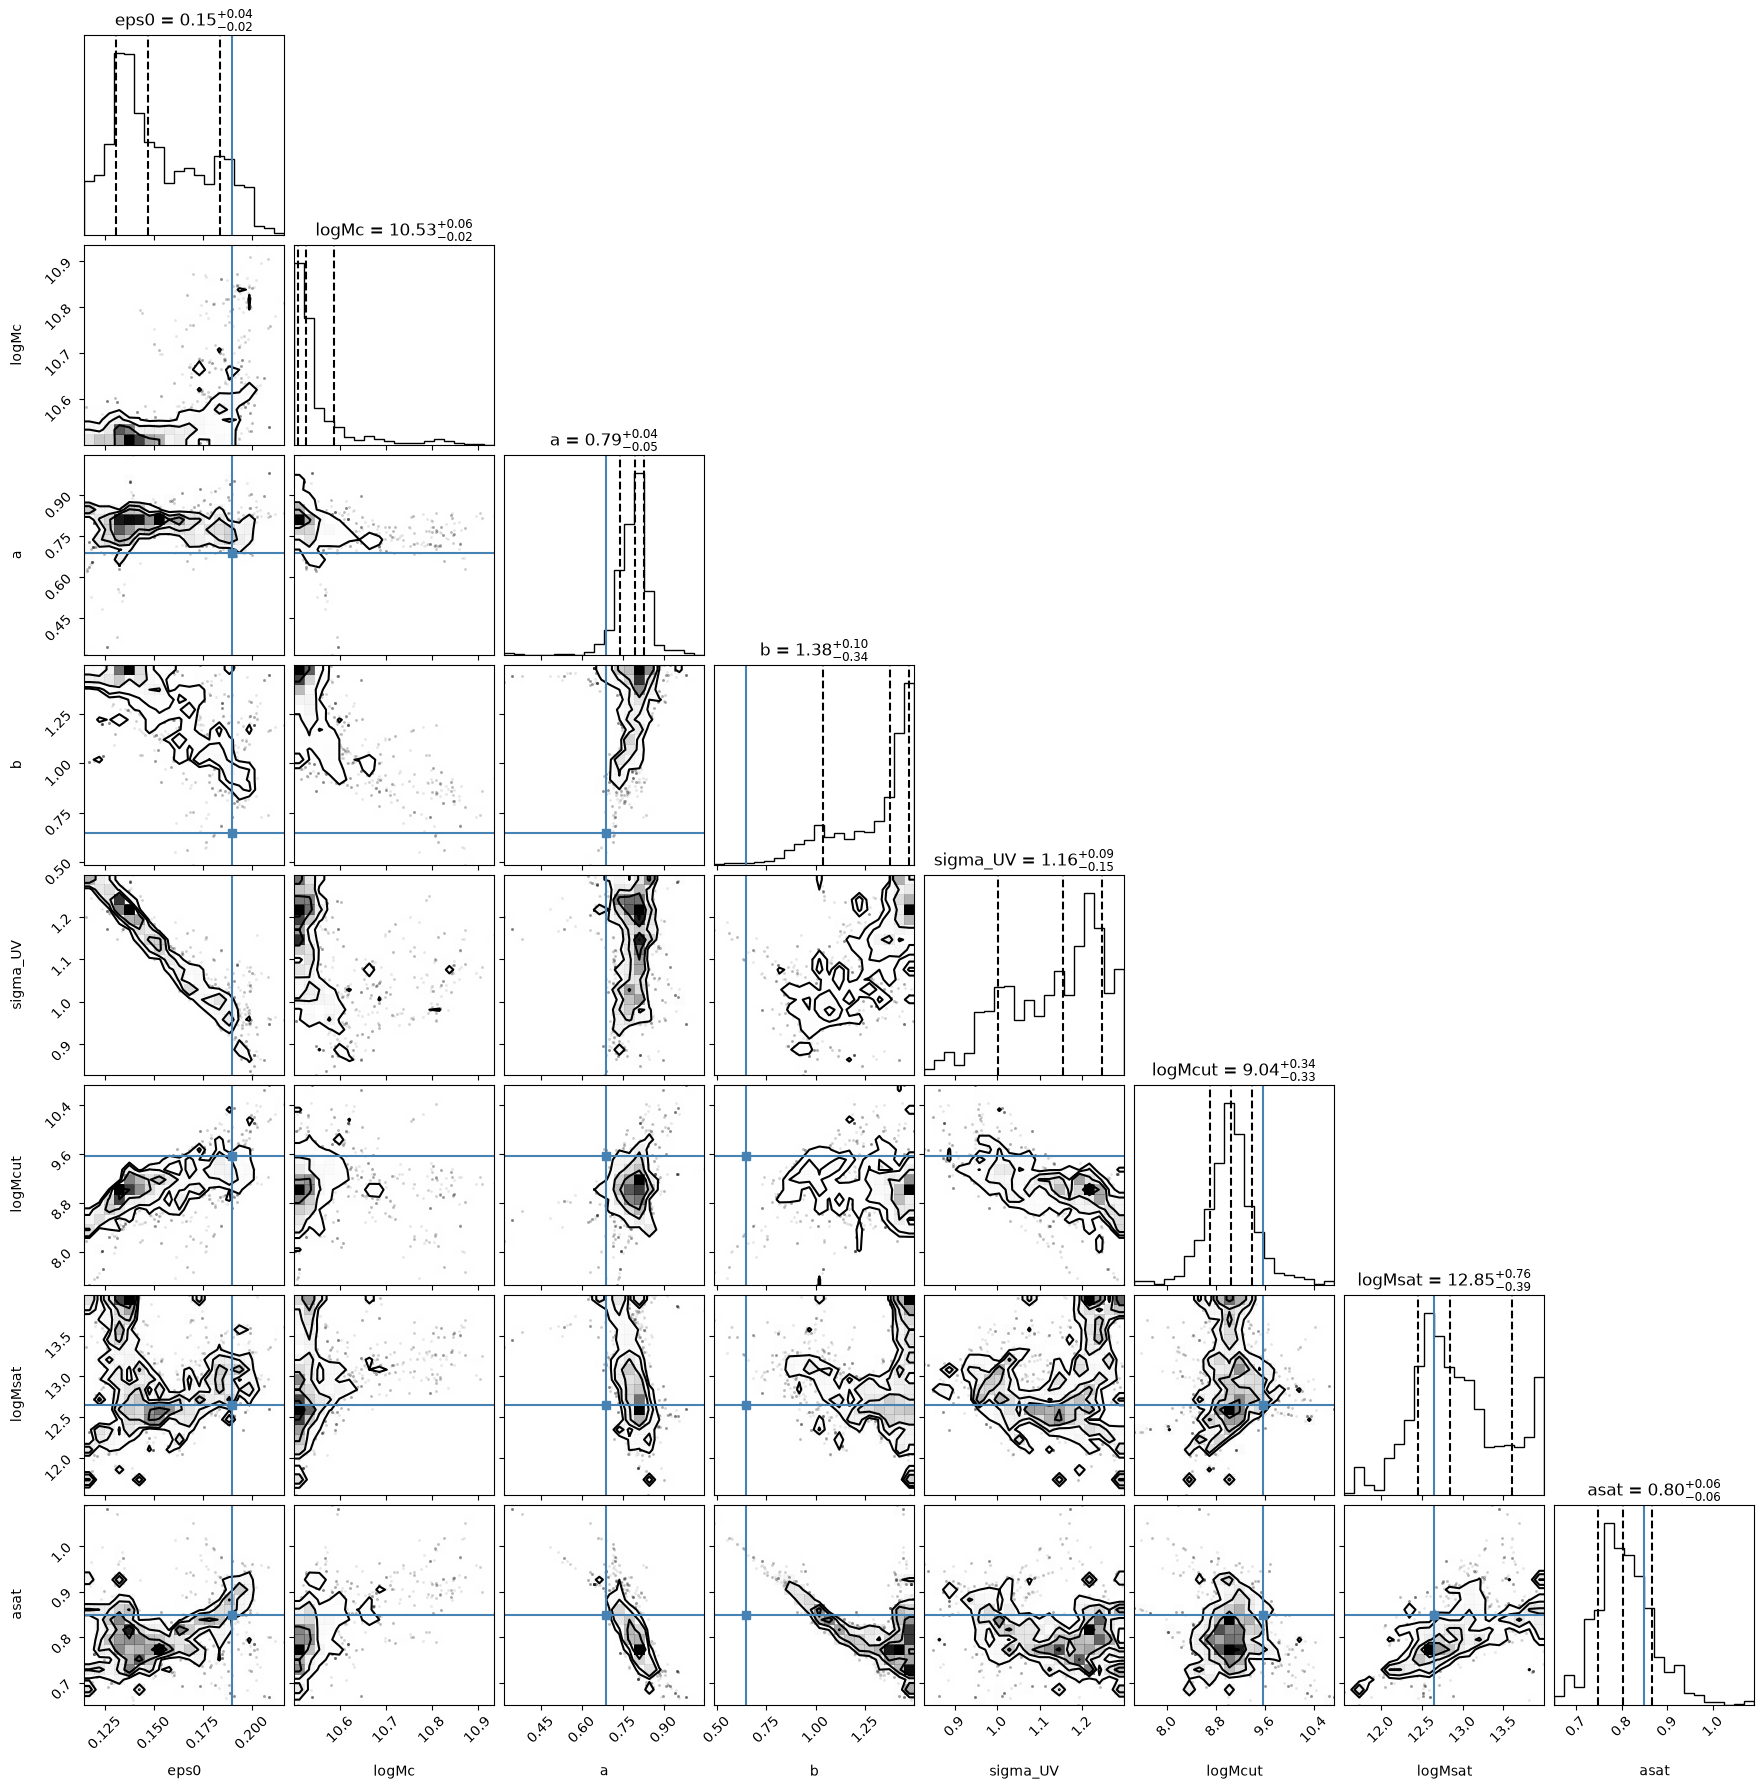

In [7]:
# Published z~5.4 values for reference (truths in the corner plot)
truths = [DEFAULT_HOD_PARAMS['eps0'], DEFAULT_HOD_PARAMS['logMc'],
          DEFAULT_HOD_PARAMS['a'], DEFAULT_HOD_PARAMS['b'],
          DEFAULT_HOD_PARAMS['sigma_UV'], DEFAULT_HOD_PARAMS['Mcut'],
          DEFAULT_HOD_PARAMS['Msat'], DEFAULT_HOD_PARAMS['asat']]
result.corner_plot(truths=truths)
plt.show()

### A note on speed: why UVLF-only can be *slower* than UVLF + clustering

The per-call cost of the forward model is dominated by the **mass-integration
grid size**, not by which observable you fit. `Observables.luminosity_function`
recomputes the (dust-iterated) $M_{\rm UV}(M_h)$ relation for every magnitude
bin over the halo-mass grid, so cost $\propto$ (grid points) $\times$ (mag bins).

- **UVLF only:** `Observables` uses the **colossus** HMF on a dense
  **2048-point** grid (its hardcoded default).
- **With clustering:** once `initialize_correlation_model` runs, the UVLF reuses
  the **halomod** HMF (~**110 points**, from `dlog10m=0.1`). That is ~18x fewer
  points, so the UVLF part becomes ~2.5x cheaper -- which is why adding
  clustering can make the *combined* call faster than UVLF-only.

The fix for UVLF-only fits is `GaussianLikelihood(..., hmf_points=HMF_POINTS)`
(used above): it pre-seeds a coarser colossus grid for clustering-free bins.
At 256 points the UVLF integral changes by <0.1% (it is smooth) for a ~2.6x
speed-up. Bins that contain clustering ignore `hmf_points` and keep the halomod
HMF for self-consistency.

### Validation: best fit vs the paper

Overlay the posterior-median model on the data, the paper's best-fit $w(\theta)$
band, and the paper's UVLF band.

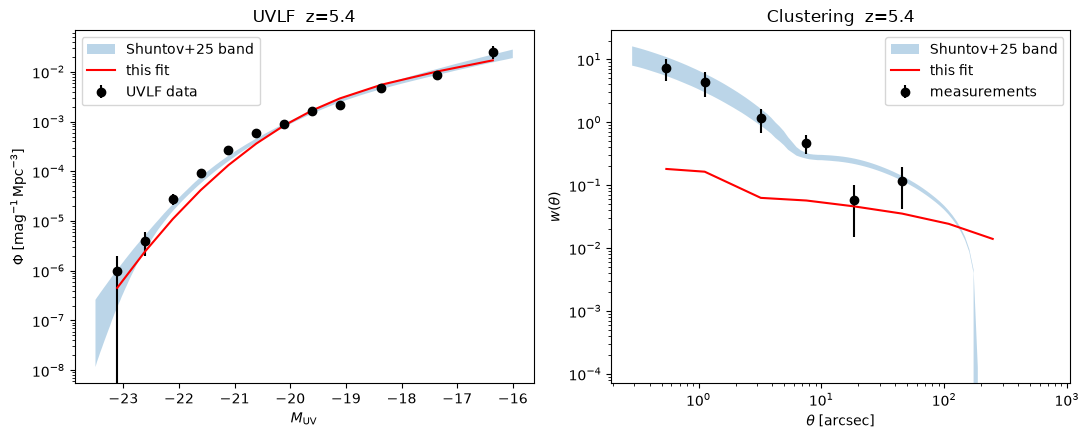

In [8]:
best = result.median_params()
pred = like.predict_all(best)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ax = axes[0]
ax.errorbar(muv, phi, yerr=err, fmt='o', color='k', label='UVLF data')
um, p16, p50, p84 = load_uvlf_bestfit('5.4')
ax.fill_between(um, p16, p84, alpha=0.3, label='Shuntov+25 band')
ax.plot(pred[uvlf_ds.label]['x'], pred[uvlf_ds.label]['model'], 'r-',
        label='this fit')
ax.set_yscale('log')
ax.set_xlabel(r'$M_{\rm UV}$')
ax.set_ylabel(r'$\Phi\;[{\rm mag^{-1}\,Mpc^{-3}}]$')
ax.legend(); ax.set_title(f'UVLF  z={z}')

ax = axes[1]
ax.errorbar(th, w, yerr=werr, fmt='o', color='k', label='measurements')
bt, bw16, bw50, bw84 = load_wtheta_bestfit(tag)
ax.fill_between(bt, bw16, bw84, alpha=0.3, label='Shuntov+25 band')
ax.plot(pred[clu_ds.label]['x'], pred[clu_ds.label]['model'], 'r-',
        label='this fit')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$\theta\;[{\rm arcsec}]$')
ax.set_ylabel(r'$w(\theta)$')
ax.legend(); ax.set_title(f'Clustering  z={z}')
plt.tight_layout(); plt.show()

## Joint redshift-evolution fit (all three bins)

Now fit the **linear redshift evolution** simultaneously across the three bins.
The free parameters are the evolution coefficients ($\mathrm{d}x/\mathrm{d}z$,
$C_x$); per-bin HOD parameters are evaluated internally via the package's
`*_fz` relations. Compare the recovered coefficients to
`DEFAULT_REDSHIFT_EVOLUTION`.

In [ ]:
datasets = []
for tag, cfg in BINS.items():
    zb = cfg['z']
    th, w, werr = load_wtheta(tag)
    muv, phi, err = uvlf_points(cfg)
    datasets.append(Dataset.uvlf(z=zb, MUV=muv, phi=phi, sigma=err,
                                 label=f'UVLF z{zb}'))
    datasets.append(Dataset.clustering(
        z=zb, theta=th, w=w, sigma=werr, MUV_thresh1=cfg['muv_thresh'],
        corr_kwargs=dict(correlation_type='angular', **HALOMOD_KW),
        label=f'w z{zb}'))

# Free a subset of evolution coefficients; the rest fall back to published
# defaults inside ModelParametrization. Priors are centred on the published
# values (DEFAULT_REDSHIFT_EVOLUTION).
EV = DEFAULT_REDSHIFT_EVOLUTION
evo = ParameterSet([
    Parameter('d_eps0_dz',  Normal(EV['d_eps0_dz'], 0.1)),
    Parameter('C_eps0',     Uniform(-0.2, 0.6)),
    Parameter('d_logMc_dz', Normal(EV['d_logMc_dz'], 0.2)),
    Parameter('C_logMc',    Uniform(9.5, 12.0)),
    Parameter('d_a_dz',     Normal(EV['d_a_dz'], 0.1)),
    Parameter('C_a',        Uniform(0.2, 1.2)),
    Parameter('d_b_dz',     Normal(EV['d_b_dz'], 0.1)),
    Parameter('C_b',        Uniform(0.2, 1.5)),
])
like_evo = GaussianLikelihood(datasets, ModelParametrization('evolution', evo),
                              hmf_points=HMF_POINTS)
like_evo

In [ ]:
# This joint fit has THREE clustering bins, so each likelihood call is ~3x the
# single-bin cost. The demo below is short; for a converged evolution
# posterior run examples/fit_shuntov25.py (mode='evolution') on many cores.
result_evo = EmceeSampler(evo, like_evo).run(
    nwalkers=24, nsteps=150, processes=NPROC, progress=True)
print(result_evo)
print()
print('Published values (DEFAULT_REDSHIFT_EVOLUTION):')
for n in evo.names:
    print(f'  {n:>12s} = {EV[n]:+.3f}')

## Model comparison with nested sampling (optional)

`DynestySampler` shares the same likelihood/prior interface and returns the
Bayesian evidence $\log Z$ -- useful for asking, e.g., whether the data justify
freeing the satellite sector. Re-run any likelihood above through it:

In [15]:
result_ns = DynestySampler(params, like).run(nlive=500)
print('log Z =', result_ns.log_evidence, '+/-', result_ns.log_evidence_err)

2267it [10:27,  1.32it/s, bound: 33 | nc: 60 | ncall: 35314 | eff(%):  6.420 | loglstar:   -inf < 54.509 <    inf | logz: 45.978 +/-  0.122 | dlogz: 51.069 >  0.010]        Traceback (most recent call last):
  File "/Users/mshuntov/opt/anaconda3/envs/halogal/lib/python3.12/site-packages/dynesty/dynesty.py", line 827, in __call__
    return self.func(np.asarray(x).copy(), *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mshuntov/CodeWorks/uvlf-hod/halogal/inference/samplers.py", line 59, in _log_likelihood
    return self.likelihood.log_likelihood(named)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mshuntov/CodeWorks/uvlf-hod/halogal/inference/likelihood.py", line 156, in log_likelihood
    return self._accumulate(named_params, reduce_fn)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mshuntov/CodeWorks/uvlf-hod/halogal/inference/likelihood.py", line 124, in _accumulate
    model = d.p

Exception while calling loglikelihood function:
  params: [ 0.069842   11.42599053  0.71242818  1.04273412  0.9635877   9.12011456
 12.01893175  0.5831313 ]
  args: []
  kwargs: {}
  exception:


KeyboardInterrupt: 

## Conclusions

- The single-bin and joint-evolution fits should recover the published HOD
  parameters and evolution coefficients, and reproduce both the $w(\theta)$ and
  UVLF best-fit bands of Shuntov+2025b.
- Remember the two `USER ACTION` inputs: the H$\alpha$/[O III] emitter UVLF
  points, and the per-bin thresholds / $p(z)$ / `halomod` keywords.
- For publication-grade clustering uncertainties, supply a **full covariance**
  for $w(\theta)$ (jackknife/bootstrap) via `cov=` rather than the diagonal
  `sigma=` used here.